In [27]:
import json
import networkx as nx
import matplotlib.pyplot as plt
from collections import defaultdict
from typing import Dict, List, Set, Tuple, Any

In [26]:
class DeclarativeKnowledge:
    def __init__(self):
        self.facts = {}
    def add_fact(self, subject, predicate, object_):
        if subject not in self.facts:
            self.facts[subject] = {}
        if predicate not in self.facts[subject]:
            self.facts[subject][predicate] = []
        self.facts[subject][predicate].append(object_)
    def query(self, subject, predicate=None):
        if subject not in self.facts:
            return None
        if predicate:
            return self.facts[subject].get(predicate, [])
        return self.facts[subject]
    def display(self):
        print("Declarative Knowledge Base:")
        print("="*50)
        for subject, predicates in self.facts.items():
            for predicate, objects in predicates.items():
                for obj in objects:
                    print(f"{subject} {predicate} {obj}")
dk = DeclarativeKnowledge()
dk.add_fact('water', 'is', 'liquid')
dk.add_fact('water', 'has', 'H2O molecule')
dk.add_fact('Paris', 'is', 'capital of France')
dk.add_fact('Paris', 'is', 'city')
dk.add_fact('Earth', 'is', 'planet')
dk.add_fact('Sun', 'is', 'star')
dk.display()
print("\nQueries:")
print(f"What is water? {dk.query('water', 'is')}")
print(f"What is Paris? {dk.query('Paris', 'is')}")

Declarative Knowledge Base:
water is liquid
water has H2O molecule
Paris is capital of France
Paris is city
Earth is planet
Sun is star

Queries:
What is water? ['liquid']
What is Paris? ['capital of France', 'city']


In [25]:
class ProceduralKnowledge:
    def __init__(self):
        self.procedures = {}
    def add_procedure(self, name, steps):
        self.procedures[name] = steps
    def execute(self, name):
        if name not in self.procedures:
            return f"Procedure '{name}' not found"
        print(f"Executing: {name}")
        print("="*50)
        for i, step in enumerate(self.procedures[name], 1):
            print(f"Step {i}: {step}")
        print("\nProcedure completed!\n")
pk = ProceduralKnowledge()
pk.add_procedure('make_tea', [
    'Boil water to 100°C',
    'Add tea leaves to teapot',
    'Pour hot water over tea leaves',
    'Steep for 4 minutes',
    'Strain and serve'
])
pk.add_procedure('solve_quadratic', [
    'Identify coefficients a, b, c in ax² + bx + c = 0',
    'Calculate discriminant: Δ = b² - 4ac',
    'If Δ < 0: No real solutions',
    'If Δ ≥ 0: x = (-b ± √Δ) / 2a'
])
pk.execute('make_tea')
pk.execute('solve_quadratic')

Executing: make_tea
Step 1: Boil water to 100°C
Step 2: Add tea leaves to teapot
Step 3: Pour hot water over tea leaves
Step 4: Steep for 4 minutes
Step 5: Strain and serve

Procedure completed!

Executing: solve_quadratic
Step 1: Identify coefficients a, b, c in ax² + bx + c = 0
Step 2: Calculate discriminant: Δ = b² - 4ac
Step 3: If Δ < 0: No real solutions
Step 4: If Δ ≥ 0: x = (-b ± √Δ) / 2a

Procedure completed!



Semantic Relationships:
Cat relations: [('is-a', 'mammal'), ('has', 'fur'), ('can', 'meow')]
Is cat an animal? True
Is cat a living thing? True
Is cat a bird? False


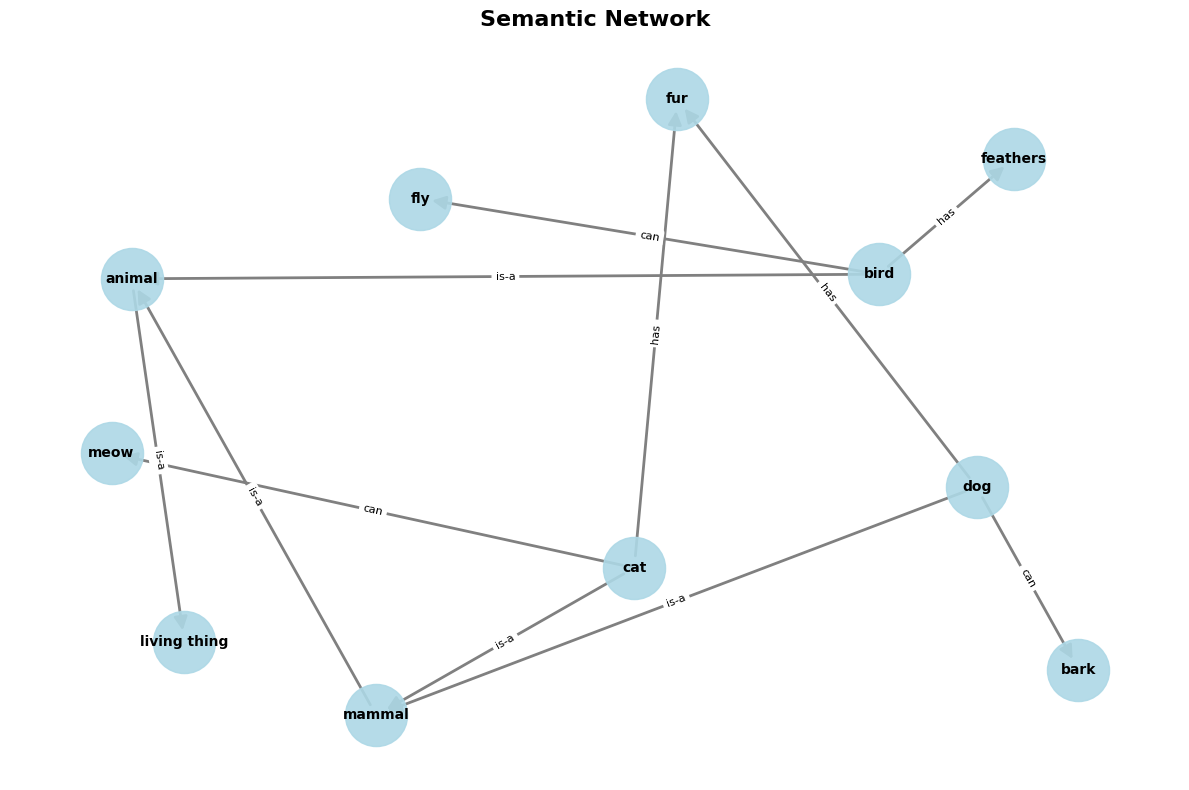

In [24]:

class SemanticNetwork:
    def __init__(self):
        self.graph = nx.DiGraph()

    def add_relation(self, concept1, relation, concept2):
        self.graph.add_edge(concept1, concept2, relation=relation)

    def get_relations(self, concept):
        relations = []
        for _, target, data in self.graph.out_edges(concept, data=True):
            relations.append((data['relation'], target))
        return relations   

    def is_a(self, concept1, concept2):
        try:
            path = nx.shortest_path(self.graph, concept1, concept2)
            for i in range(len(path) - 1):
                edge_dataset = self.graph[path[i]][path[i+1]]
                if edge_dataset['relation'] != 'is-a':
                    return False
            return True
        except nx.NetworkXNoPath:
            return False

    def visualize(self):
        plt.figure(figsize=(12, 8))
        pos = nx.spring_layout(self.graph, k=2, iterations=50)

        nx.draw_networkx_nodes(self.graph, pos, node_color='lightblue',
                               node_size=2000, alpha=0.9)

        nx.draw_networkx_edges(self.graph, pos, edge_color='gray',
                               arrows=True, arrowsize=20, width=2)

        nx.draw_networkx_labels(self.graph, pos, font_size=10, font_weight='bold')

        edge_labels = nx.get_edge_attributes(self.graph, 'relation')
        nx.draw_networkx_edge_labels(self.graph, pos, edge_labels, font_size=8)

        plt.title('Semantic Network', fontsize=16, fontweight='bold')
        plt.axis('off')
        plt.tight_layout()
        plt.show()


sn = SemanticNetwork()

sn.add_relation('cat', 'is-a', 'mammal')
sn.add_relation('dog', 'is-a', 'mammal')
sn.add_relation('bird', 'is-a', 'animal')
sn.add_relation('mammal', 'is-a', 'animal')
sn.add_relation('animal', 'is-a', 'living thing')

sn.add_relation('cat', 'has', 'fur')
sn.add_relation('cat', 'can', 'meow')

sn.add_relation('dog', 'has', 'fur')
sn.add_relation('dog', 'can', 'bark')

sn.add_relation('bird', 'has', 'feathers')
sn.add_relation('bird', 'can', 'fly')

print("Semantic Relationships:")
print("="*50)

print(f"Cat relations: {sn.get_relations('cat')}")
print(f"Is cat an animal? {sn.is_a('cat', 'animal')}")
print(f"Is cat a living thing? {sn.is_a('cat', 'living thing')}")
print(f"Is cat a bird? {sn.is_a('cat', 'bird')}")

sn.visualize()

In [23]:
from datetime import datetime
class EpisodicMemory:
    def __init__(self):
        self.episodes = []
    def add_episode(self, event, location, time, participants=None, details=None):
        episode = {
            'event': event,
            'location': location,
            'time': time,
            'participants': participants or [],
            'details': details or {}
        }
        self.episodes.append(episode)
    def recall_by_location(self, location):
        return [ep for ep in self.episodes if ep['location'] == location]
    def recall_by_time(self, time_period):
        return [ep for ep in self.episodes if time_period in ep['time']]
    def recall_recent(self, n=5):
        return self.episodes[-n:]
    def display_episode(self, episode):
        print(f"Event: {episode['event']}")
        print(f"Location: {episode['location']}")
        print(f"Time: {episode['time']}")
        if episode['participants']:
            print(f"Participants: {', '.join(episode['participants'])}")
        if episode['details']:
            print("Details:")
            for key, value in episode['details'].items():
                print(f"  - {key}: {value}")
        print()
em = EpisodicMemory()
em.add_episode(
    'Visited Eiffel Tower',
    'Paris, France',
    'July 2020',
    ['Ali', 'Baber'],
    {'weather': 'sunny', 'activity': 'sightseeing'}
)
em.add_episode(
    'Team Meeting',
    'Office Conference Room',
    'Monday, 3 PM',
    ['Jamil', 'Shakeela', 'Mohammad'],
    {'topic': 'Project planning', 'duration': '2 hours'}
)
em.add_episode(
    'Birthday Party',
    'Home',
    'December 15, 2023',
    ['Family', 'Friends'],
    {'cake': 'chocolate', 'gifts': 'received many'}
)
print("Episodic Memory - Recent Episodes:")
print("="*50)
for episode in em.recall_recent(3):
    em.display_episode(episode)
print("\nRecalling episodes in Paris:")
print("="*50)
for episode in em.recall_by_location('Paris, France'):
    em.display_episode(episode)

Episodic Memory - Recent Episodes:
Event: Visited Eiffel Tower
Location: Paris, France
Time: July 2020
Participants: Ali, Baber
Details:
  - weather: sunny
  - activity: sightseeing

Event: Team Meeting
Location: Office Conference Room
Time: Monday, 3 PM
Participants: Jamil, Shakeela, Mohammad
Details:
  - topic: Project planning
  - duration: 2 hours

Event: Birthday Party
Location: Home
Time: December 15, 2023
Participants: Family, Friends
Details:
  - cake: chocolate
  - gifts: received many


Recalling episodes in Paris:
Event: Visited Eiffel Tower
Location: Paris, France
Time: July 2020
Participants: Ali, Baber
Details:
  - weather: sunny
  - activity: sightseeing



In [14]:
class MetaKnowledge:
    def __init__(self):
        self.knowledge_base = {}
        self.metadataset = {}
    def add_knowledge(self, key, value, source=None, confidence=1.0, 
                     date=None, certainty='certain'):
        self.knowledge_base[key] = value
        self.metadataset[key] = {
            'source': source,
            'confidence': confidence,
            'date': date or datetime.now().strftime('%Y-%m-%d'),
            'certainty': certainty
        }
    def get_knowledge(self, key):
        if key in self.knowledge_base:
            return {
                'value': self.knowledge_base[key],
                'metadataset': self.metadataset[key]
            }
        return None
    def assess_reliability(self, key):
        if key not in self.metadataset:
            return "Unknown"
        meta = self.metadataset[key]
        confidence = meta['confidence']
        if confidence >= 0.9:
            return "Highly reliable"
        elif confidence >= 0.7:
            return "Moderately reliable"
        elif confidence >= 0.5:
            return "Questionable"
        else:
            return "Unreliable"
    def display_knowledge(self, key):
        knowledge = self.get_knowledge(key)
        if not knowledge:
            print(f"No knowledge about '{key}'")
            return
        print(f"Knowledge: {key}")
        print(f"Value: {knowledge['value']}")
        print(f"Source: {knowledge['metadataset']['source']}")
        print(f"Confidence: {knowledge['metadataset']['confidence']:.2f}")
        print(f"Certainty: {knowledge['metadataset']['certainty']}")
        print(f"Date: {knowledge['metadataset']['date']}")
        print(f"Reliability: {self.assess_reliability(key)}")
        print()
mk = MetaKnowledge()
mk.add_knowledge(
    'speed_of_light',
    '299,792,458 m/s',
    source='Scientific measurement',
    confidence=1.0,
    certainty='certain'
)
mk.add_knowledge(
    'weather_tomorrow',
    'sunny',
    source='Weather forecast',
    confidence=0.75,
    certainty='probable'
)
mk.add_knowledge(
    'aliens_exist',
    'unknown',
    source='Speculation',
    confidence=0.3,
    certainty='uncertain'
)
print("Meta-knowledge System:")
print("="*50)
mk.display_knowledge('speed_of_light')
mk.display_knowledge('weather_tomorrow')
mk.display_knowledge('aliens_exist')

Meta-knowledge System:
Knowledge: speed_of_light
Value: 299,792,458 m/s
Source: Scientific measurement
Confidence: 1.00
Certainty: certain
Date: 2026-03-07
Reliability: Highly reliable

Knowledge: weather_tomorrow
Value: sunny
Source: Weather forecast
Confidence: 0.75
Certainty: probable
Date: 2026-03-07
Reliability: Moderately reliable

Knowledge: aliens_exist
Value: unknown
Source: Speculation
Confidence: 0.30
Certainty: uncertain
Date: 2026-03-07
Reliability: Unreliable



In [22]:
class Frame:
    def __init__(self, name):
        self.name = name
        self.slots = {}
        self.parent = None
    def add_slot(self, slot_name, value, default=None):
        self.slots[slot_name] = {'value': value, 'default': default}
    def get_slot(self, slot_name):
        if slot_name in self.slots:
            return self.slots[slot_name]['value']
        if self.parent:
            return self.parent.get_slot(slot_name)
        return None
    def set_parent(self, parent):
        self.parent = parent
    def display(self, indent=0):
        prefix = "  " * indent
        print(f"{prefix}Frame: {self.name}")
        if self.parent:
            print(f"{prefix}  Parent: {self.parent.name}")
        for slot_name, slot_dataset in self.slots.items():
            print(f"{prefix}  {slot_name}: {slot_dataset['value']}")
print("Frame-based Knowledge Representation:")
print("="*50)
vehicle = Frame('Vehicle')
vehicle.add_slot('type', 'transportation')
vehicle.add_slot('has_wheels', True)
car = Frame('Car')
car.set_parent(vehicle)
car.add_slot('num_wheels', 4)
car.add_slot('has_engine', True)
my_car = Frame('Toyota')
my_car.set_parent(car)
my_car.add_slot('color', 'red')
my_car.add_slot('model', 'Grande')
my_car.add_slot('year', 2024)
vehicle.display()
print()
car.display()
print()
my_car.display()
print(f"\nMy car has wheels? {my_car.get_slot('has_wheels')}")
print(f"My car type: {my_car.get_slot('type')}")

Frame-based Knowledge Representation:
Frame: Vehicle
  type: transportation
  has_wheels: True

Frame: Car
  Parent: Vehicle
  num_wheels: 4
  has_engine: True

Frame: Toyota
  Parent: Car
  color: red
  model: Grande
  year: 2024

My car has wheels? True
My car type: transportation


In [20]:
class ProductionRule:
    def __init__(self, name, conditions, actions):
        self.name = name
        self.conditions = conditions
        self.actions = actions
    def evaluate(self, facts):
        for condition in self.conditions:
            key, value = condition
            if key not in facts or facts[key] != value:
                return False
        return True
    def execute(self, facts):
        if self.evaluate(facts):
            print(f"Rule '{self.name}' fired!")
            for action in self.actions:
                print(f"  Action: {action}")
            return True
        return False
class ProductionSystem:
    def __init__(self):
        self.rules = []
        self.facts = {}
    def add_rule(self, rule):
        self.rules.append(rule)
    def add_fact(self, key, value):
        self.facts[key] = value
    def run(self):
        print("Running Production System...")
        print("="*50)
        print(f"Facts: {self.facts}\n")
        fired_any = False
        for rule in self.rules:
            if rule.execute(self.facts):
                fired_any = True
                print()
        if not fired_any:
            print("No rules fired.")
ps = ProductionSystem()
ps.add_rule(ProductionRule(
    'Grant Loan',
    [('income', 'high'), ('credit_score', 'good')],
    ['Approve loan application', 'Send approval email']
))
ps.add_rule(ProductionRule(
    'Reject Loan',
    [('income', 'low'), ('credit_score', 'poor')],
    ['Reject loan application', 'Send rejection email with reasons']
))
ps.add_rule(ProductionRule(
    'Request More Info',
    [('income', 'medium')],
    ['Request additional documentation', 'Schedule interview']
))
ps.add_fact('income', 'high')
ps.add_fact('credit_score', 'good')
ps.run()

Running Production System...
Facts: {'income': 'high', 'credit_score': 'good'}

Rule 'Grant Loan' fired!
  Action: Approve loan application
  Action: Send approval email



Ontology Example: University Domain

Ontology Queries:
Is Undergraduate a subclass of Person? True
Ancestors of Undergraduate: ['Student', 'Person']
Ali's properties: {'major': 'Computer Science', 'year': 3}


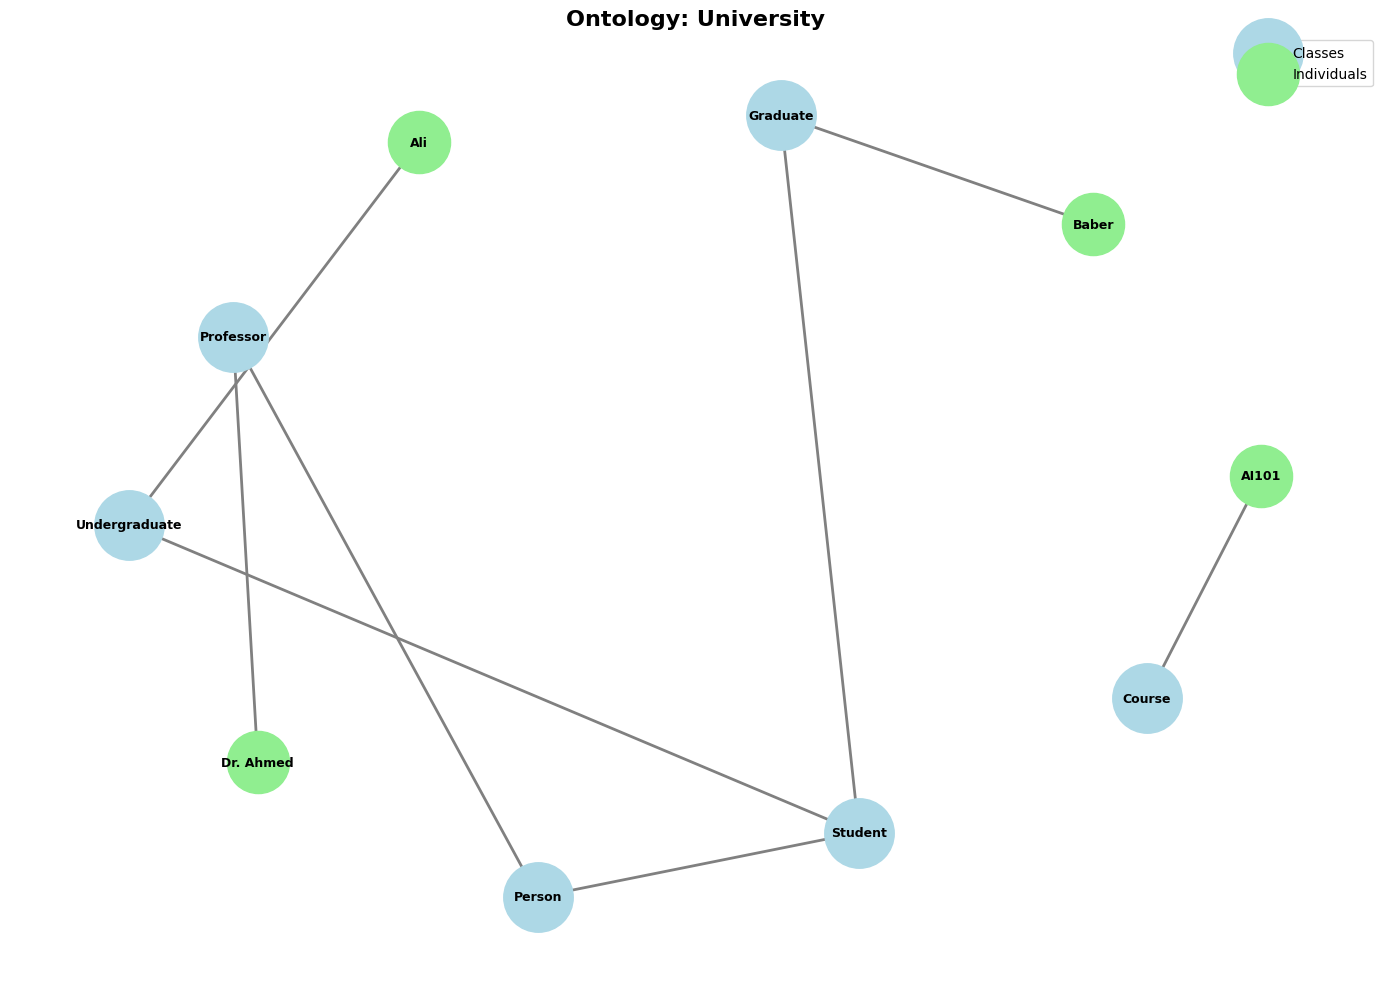

In [21]:
class Ontology:
    def __init__(self, name):
        self.name = name
        self.classes = {}
        self.individuals = {}
        self.properties = defaultdict(dict)
    def add_class(self, class_name, parent=None):
        self.classes[class_name] = {'parent': parent, 'children': []}
        if parent and parent in self.classes:
            self.classes[parent]['children'].append(class_name)
    def add_individual(self, name, class_name):
        self.individuals[name] = class_name
    def add_property(self, individual, property_name, value):
        self.properties[individual][property_name] = value
    def is_subclass_of(self, class1, class2):
        if class1 == class2:
            return True
        current = class1
        while current in self.classes and self.classes[current]['parent']:
            current = self.classes[current]['parent']
            if current == class2:
                return True
        return False
    def get_ancestors(self, class_name):
        ancestors = []
        current = class_name
        while current in self.classes and self.classes[current]['parent']:
            parent = self.classes[current]['parent']
            ancestors.append(parent)
            current = parent
        return ancestors
    def visualize(self):
        G = nx.DiGraph()
        for class_name, class_dataset in self.classes.items():
            G.add_node(class_name, type='class')
            if class_dataset['parent']:
                G.add_edge(class_dataset['parent'], class_name, rel='subclass')
        for individual, class_name in self.individuals.items():
            G.add_node(individual, type='individual')
            G.add_edge(class_name, individual, rel='instance')
        plt.figure(figsize=(14, 10))
        pos = nx.spring_layout(G, k=3, iterations=50)

        class_nodes = [n for n, d in G.nodes(data=True) if d.get('type') == 'class']
        individual_nodes = [n for n, d in G.nodes(data=True) if d.get('type') == 'individual']

        nx.draw_networkx_nodes(G, pos, nodelist=class_nodes,
                       node_color='lightblue', node_size=2500, label='Classes')
        nx.draw_networkx_nodes(G, pos, nodelist=individual_nodes,
                       node_color='lightgreen', node_size=2000, label='Individuals')
        nx.draw_networkx_edges(G, pos, edge_color='gray', arrows=True, 
                              arrowsize=20, width=2)
        nx.draw_networkx_labels(G, pos, font_size=9, font_weight='bold')
        plt.title(f'Ontology: {self.name}', fontsize=16, fontweight='bold')
        plt.legend()
        plt.axis('off')
        plt.tight_layout()
        plt.show()
print("Ontology Example: University Domain")
print("="*50)
onto = Ontology('University')
onto.add_class('Person')
onto.add_class('Student', 'Person')
onto.add_class('Professor', 'Person')
onto.add_class('Undergraduate', 'Student')
onto.add_class('Graduate', 'Student')
onto.add_class('Course')
onto.add_individual('Ali', 'Undergraduate')
onto.add_individual('Baber', 'Graduate')
onto.add_individual('Dr. Ahmed', 'Professor')
onto.add_individual('AI101', 'Course')
onto.add_property('Ali', 'major', 'Computer Science')
onto.add_property('Ali', 'year', 3)
onto.add_property('Baber', 'research_area', 'Machine Learning')
onto.add_property('Dr. Ahmed', 'department', 'Computer Science')
onto.add_property('AI101', 'instructor', 'Dr. Ahmed')
print("\nOntology Queries:")
print(f"Is Undergraduate a subclass of Person? {onto.is_subclass_of('Undergraduate', 'Person')}")
print(f"Ancestors of Undergraduate: {onto.get_ancestors('Undergraduate')}")
print(f"Ali's properties: {dict(onto.properties['Ali'])}")
onto.visualize()